In [242]:
import pandas as pd
import numpy as np

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns

In [244]:
train=pd.read_csv(r"/content/Titanic_train.csv")
test=pd.read_csv(r"/content/Titanic_test.csv")

In [245]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [246]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Dictionary
- Survived: 0 = No, 1 = Yes
- pclass: Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd
- sibsp: # of siblings / spouses aboard the Titanic
- parch: # of parents / children aboard the Titanic
- ticket: Ticket number
- cabin: Cabin number
- embarked: Port of Embarkation C = Cherbourg, Q = Queenstown, S = Southampton

In [247]:
#remove the columns which is not needed(Name ,Ticket ,passengerId,cabin)
train.drop(['Ticket', 'PassengerId', 'Cabin'], axis=1, inplace=True)
test.drop(['Ticket', 'PassengerId', 'Cabin'], axis=1, inplace=True)

In [248]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [249]:
train.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [250]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      417 non-null    float64
 7   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 26.3+ KB


In [251]:
test.isnull().sum()

,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Embarked,0


# Bar Chart for categorical Features
- PClass
- Sex
- SibSp (# of siblings and spouse)
- ParCh (# of parrents and children)
- Embarked
- Cabin

In [252]:
# function to build a bar chart for a specified feature to visualize the distribution of survivors and non-survivors
def build_bar_chart(feature):
    survived = train[train['Survived']==1][feature].value_counts()
    dead = train[train['Survived']==0][feature].value_counts()

    df = pd.DataFrame([survived, dead])
    df.index = ['Survived', 'Dead']
    df.plot(kind='bar', stacked=True,figsize=(10, 5))

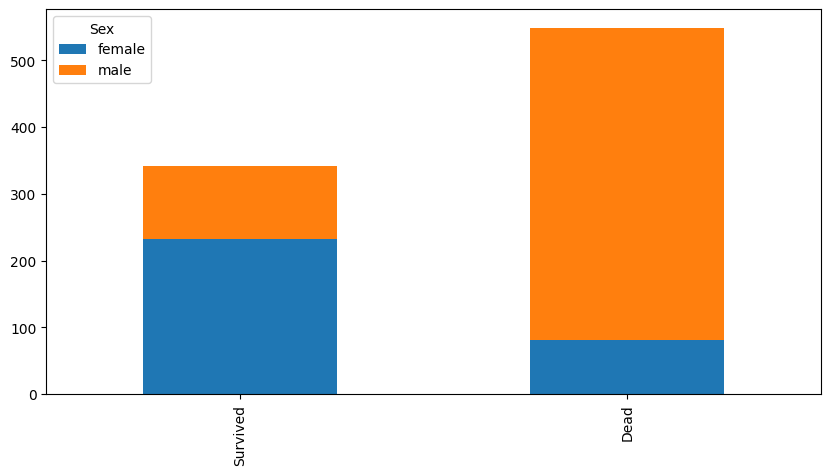

In [253]:
build_bar_chart('Sex')

That confirms **Women** more likely survived than **Men**

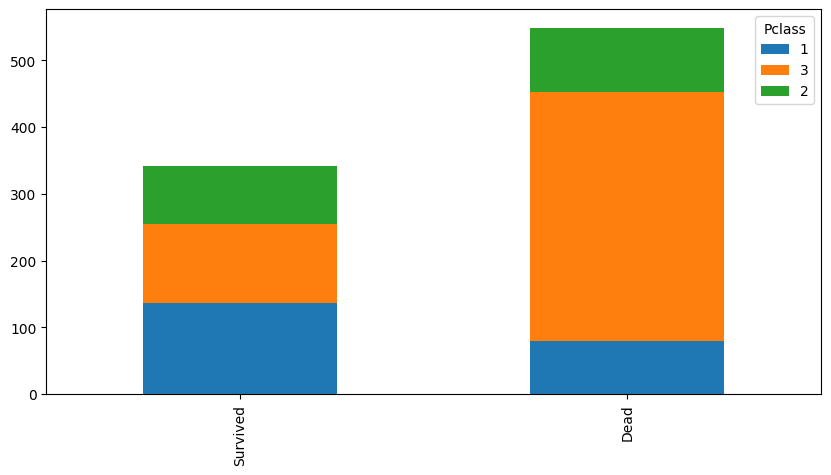

In [254]:
build_bar_chart('Pclass')

The Chart confirms **1st** class more likely survivied than **other classes**

The Chart confirms **3rd** class more likely dead than **other classes**

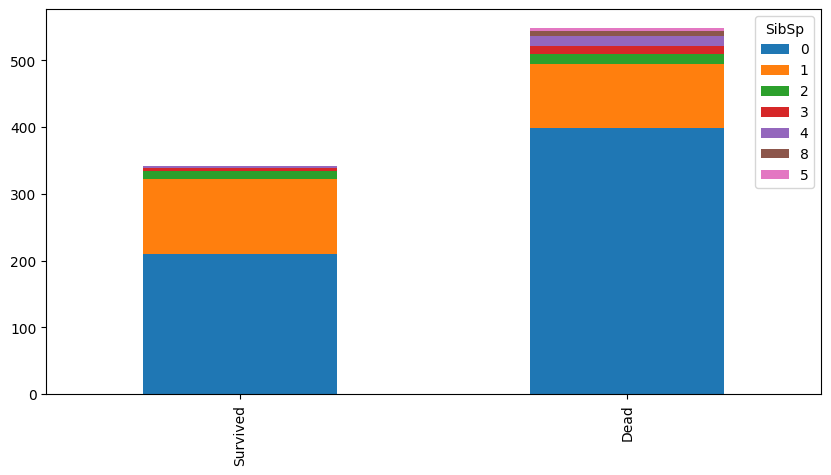

In [255]:
build_bar_chart('SibSp')

The Chart confirms **a person aboard alone** was more likely to die

The Chart confirms **a person with 1 or 2 siblings or spouses** was more likely to survive.

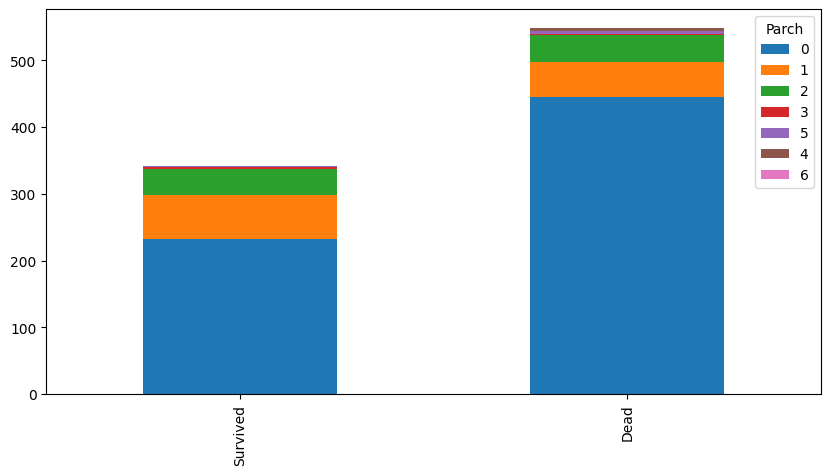

In [256]:
build_bar_chart('Parch')

The Chart confirms **a person aboard alone** was more likely to die

The Chart confirms **a person with 1 or 2 family members** was more likely to survive.

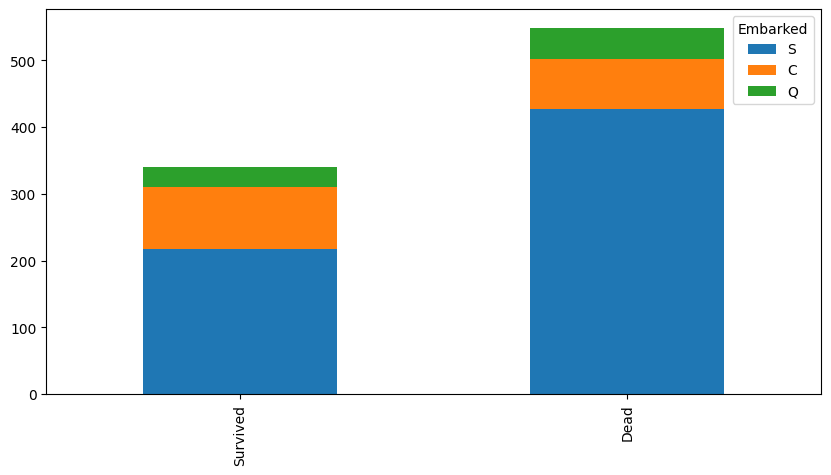

In [257]:
build_bar_chart('Embarked')

The Chart confirms **a person aboarded from C** slightly more likely survived

The Chart confirms **a person aboarded from Q** more likely dead

The Chart confirms **a person aboarded from S** more likely dead


# Feature Engineering

In [258]:
from IPython.display import Image
Image(url= "https://static1.squarespace.com/static/5006453fe4b09ef2252ba068/t/5090b249e4b047ba54dfd258/1351660113175/TItanic-Survival-Infographic.jpg?format=1500w")

In [259]:
train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [260]:
#combining train and test datasets for easier data manipulation and extraction title from the name column
train_test_data = [train, test]
for dataset in train_test_data:
    dataset['Title'] = dataset['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [261]:
#crating new features for family size and whether the passenger is alone or not
for dataset in train_test_data:
    dataset["FamilySize"] = dataset["SibSp"] + dataset["Parch"] + 1
    dataset["Alone"] = (dataset["FamilySize"] == 1).astype(int)

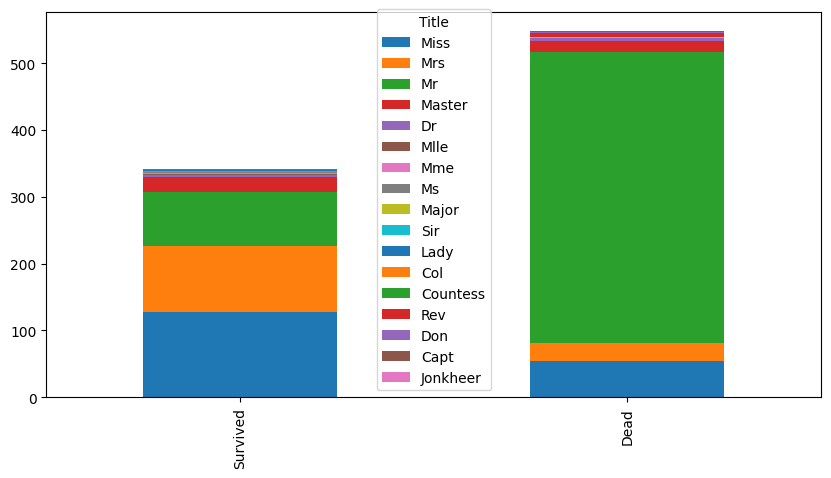

In [262]:
build_bar_chart('Title')

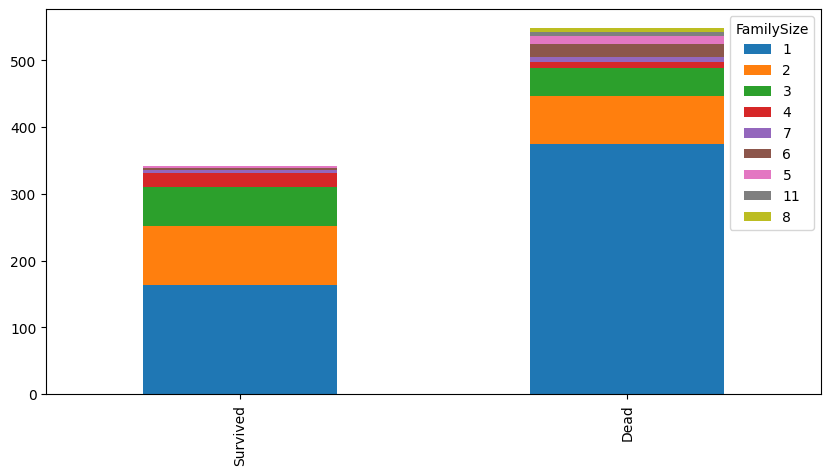

In [263]:
build_bar_chart('FamilySize')

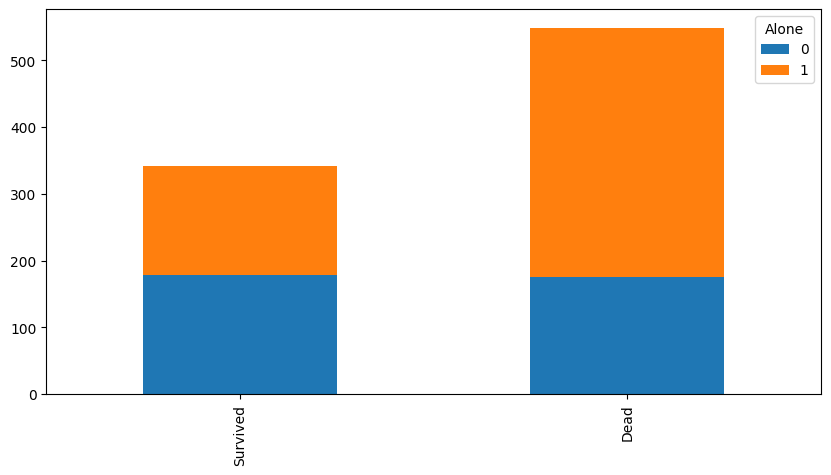

In [264]:
build_bar_chart('Alone')

In [265]:
#drop Name column after extracting the title from it
drop_cols = ["Name"]
train = train.drop(drop_cols, axis=1)
test = test.drop(drop_cols, axis=1)

# Missing Value Handling

In [266]:
#checking for missing values after feature engineering
train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
Title,0
FamilySize,0


In [267]:
test.isnull().sum()

,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Embarked,0
Title,0
FamilySize,0
Alone,0


In [268]:
# fill missing age with median age for each title (Mr, Mrs, Miss, Others)
train["Age"] = train["Age"].fillna(train.groupby("Title")["Age"].transform("median"))
test["Age"] = test["Age"].fillna(test.groupby("Title")["Age"].transform("median"))

#fill missing age if it still exists with fallback median age in test dataset
test["Age"] = test["Age"].fillna(train["Age"].median())

In [269]:
# fill missing embarked with the most common value
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])

In [270]:
#fill missing fare with median fare for each Pclass
test["Fare"] = test["Fare"].fillna(test.groupby("Pclass")["Fare"].transform("median"))

In [271]:
#checking for missing values after Handling missing values
train.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Title,0
FamilySize,0


In [272]:
test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Title,0
FamilySize,0
Alone,0


# Checking for Outliers in numeric Features

In [273]:
# function to create a box plot that displays outliers
def plot_boxplot_with_outliers(feature, data):
    plt.figure(figsize=(12, 6))
    sns.boxplot(y=feature, data=data, palette='Set2',
                fliersize=8, flierprops=dict(marker='o', markerfacecolor='red', markersize=8, alpha=0.7))
    plt.title(f'Box Plot of {feature} (Outliers Highlighted in Red)', fontsize=14, fontweight='bold')
    plt.ylabel(feature, fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Map dictionary
- 0--> MR
- 1--> Miss
- 2--> Mrs
- 3--> Other

In [274]:
title_mapping = {
    "Mr": 0,
    "Miss": 1,
    "Mrs": 2,
    "Master": 3,
    "Dr": 3,
    "Jonkheer": 3,
    "Rev": 3,
    "Col": 3,
    "Major": 3,
    "Mlle": 3,
    "Countess": 3,
    "Ms": 3,
    "Sir": 3,
    "Capt": 3,
    "Mme": 3,
    "Lady": 3,
    "Don": 3,
    "Dona": 3
}
train['Title'] = train['Title'].map(title_mapping)
test['Title'] = test['Title'].map(title_mapping)

# Map dictionary
- male-->0
- female-->1

In [275]:
sex_mapping={"male":0,"female":1}
train['Sex'] = train['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

# Map dictionary
- C-->Cherbourg-->1
- Q-->Queenstown-->2
- S-->Southampton-->0

In [276]:
embarked_mapping={"S":0,"C":1,"Q":2}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)

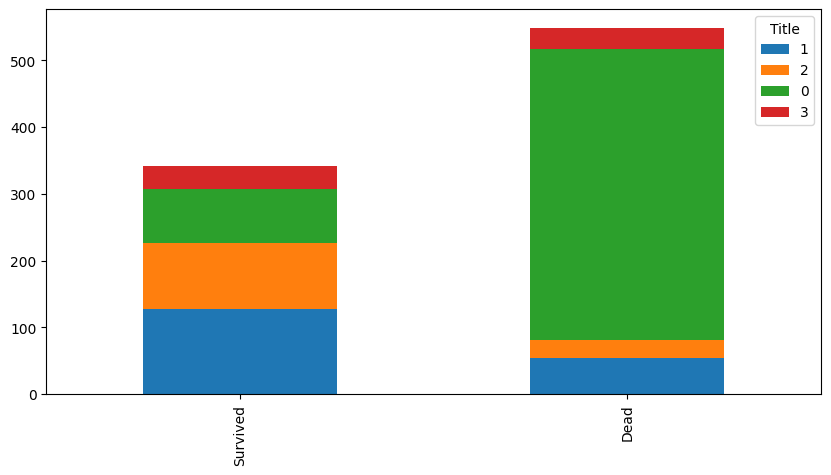

In [277]:
build_bar_chart('Title')

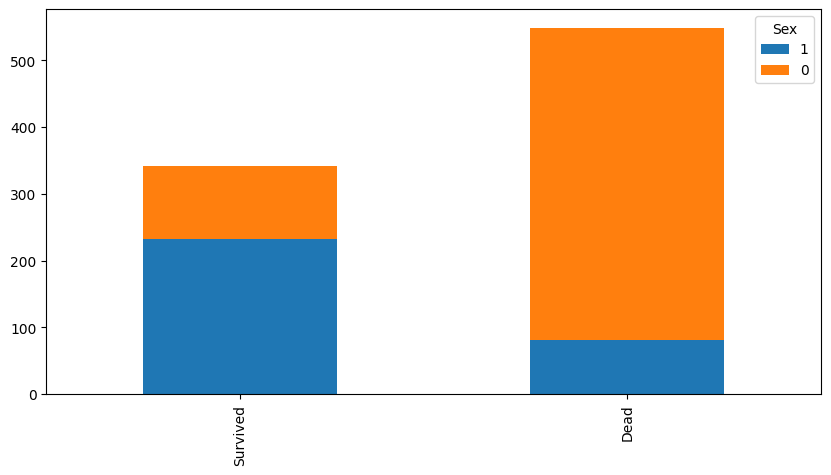

In [278]:
build_bar_chart('Sex')

this shows that **males are the most who died** in the accident

## Model Building: Logistic Regression

In [279]:
# Separate target variable from features
from sklearn.model_selection import train_test_split
X = train.drop('Survived', axis=1)
y = train['Survived']

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [280]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical features to scale
numerical_cols = ['Age', 'Fare', 'FamilySize']

# Apply scaling to training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaled training data head:")
display(X_train.head())
print("\nScaled testing data head:")
display(X_test.head())

Scaled training data head:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,Alone
331,1,0,1.229075,0,0,-0.078684,0,0,-0.554666,1
733,2,0,-0.476087,0,0,-0.377145,0,0,-0.554666,1
382,3,0,0.205978,0,0,-0.474867,0,0,-0.554666,1
704,3,0,-0.248732,1,0,-0.476230,0,0,0.040096,0
813,3,1,-1.764432,4,2,-0.025249,0,1,3.013909,0



Scaled testing data head:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,Alone
709,3,0,-1.953894,1,1,-0.333901,1,3,0.634859,0
439,2,0,0.130193,0,0,-0.425284,0,0,-0.554666,1
840,3,0,-0.703442,0,0,-0.474867,0,0,-0.554666,1
720,2,1,-1.764432,0,1,0.007966,0,1,0.040096,0
39,3,1,-1.158152,1,0,-0.411002,1,1,0.040096,0


In [281]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
logreg = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=200
)
logreg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [282]:
# Make predictions on the test set
y_pred = logreg.predict(X_test)

print("Predictions made on the test set.")

Predictions made on the test set.


In [283]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Since we are working with train/test split, we can evaluate on the training data for demonstration.
# In a real scenario, you would use a separate validation set.

y_train_pred = logreg.predict(X_train)
train_acc_log=accuracy_score(y_train, y_train_pred)
test_acc_log=accuracy_score(y_test, y_pred)
print(f"Training Accuracy: {train_acc_log*100:.2f}%")
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))

Training Accuracy: 82.16%

Training Confusion Matrix:
 [[387  57]
 [ 70 198]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])

Training Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       444
           1       0.78      0.74      0.76       268

    accuracy                           0.82       712
   macro avg       0.81      0.81      0.81       712
weighted avg       0.82      0.82      0.82       712



In [284]:
print(f"Test Accuracy: {test_acc_log*100:.2f}%")

# The confusion matrix provides a summary of prediction results on a classification problem.
# It shows the number of correct and incorrect predictions broken down by each class.
print("\nTest Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")

print("\nTest Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 80.45%

Test Confusion Matrix:
 [[87 18]
 [17 57]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])

Test Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83       105
           1       0.76      0.77      0.77        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



**Anlyzing to make sure from over fitting**

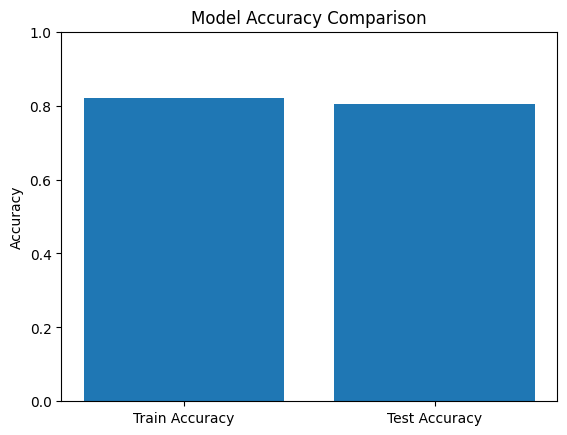

In [285]:
scores = [train_acc_log, test_acc_log]
labels = ['Train Accuracy', 'Test Accuracy']

plt.bar(labels, scores)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [286]:
feature_names = X.columns
coefficients = logreg.coef_[0]

for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.3f}")

Pclass: -0.800
Sex: 1.932
Age: -0.384
SibSp: -0.292
Parch: -0.102
Fare: 0.236
Embarked: 0.168
Title: 0.723
FamilySize: -0.442
Alone: -0.415


Gender is the strongest predictor (**females more likely to survive**)

Higher class and higher fare
**increase** survival chances

Larger families and being alone both **decrease** survival probability

Age slightly **decreases** survival

# Modeling using Decision Tree


In [287]:
#To ensure from the pest Accuracy at Max_depth

In [288]:
from sklearn.tree  import DecisionTreeClassifier
depths= range(1,11)
accuracies =[]
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(f"max_depth={d} -> accuracy={acc}")

max_depth=1 -> accuracy=0.7821229050279329
max_depth=2 -> accuracy=0.7597765363128491
max_depth=3 -> accuracy=0.8156424581005587
max_depth=4 -> accuracy=0.8324022346368715
max_depth=5 -> accuracy=0.8324022346368715
max_depth=6 -> accuracy=0.8324022346368715
max_depth=7 -> accuracy=0.8268156424581006
max_depth=8 -> accuracy=0.8212290502793296
max_depth=9 -> accuracy=0.8212290502793296
max_depth=10 -> accuracy=0.7932960893854749


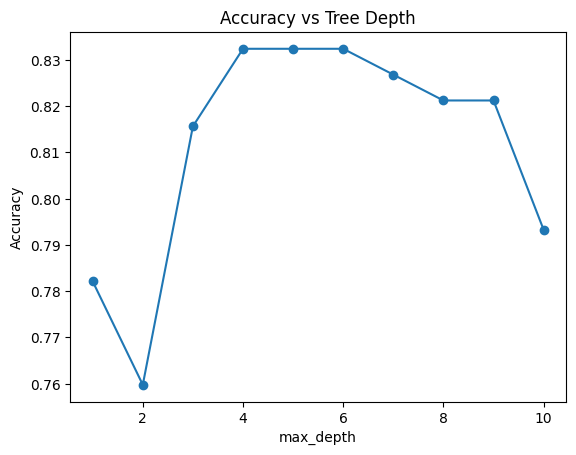

In [289]:
plt.plot(depths, accuracies, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.show()

**the best Accuracy at Max_depth** =(4 ,5 , 6) we will **choose 4** to be more simple and avoid over fitting

In [290]:
model=DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [291]:
predictions_test=model.predict(X_test)
predictions_train=model.predict(X_train)

[[92 13]
 [17 57]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])


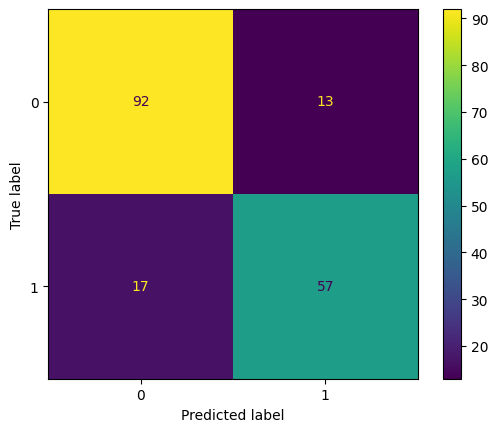

In [292]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions_test)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print(cm)
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")
plt.show()

In [293]:
train_acc = accuracy_score(y_train, predictions_train)
test_acc = accuracy_score(y_test, predictions_test)
print (f" Test_acc = {test_acc*100:.2f}%")
print (f"Train_acc = {train_acc*100:.2f}%")

 Test_acc = 83.24%
Train_acc = 84.27%


**Analyzing bar chart to make sure there is no over fitting**


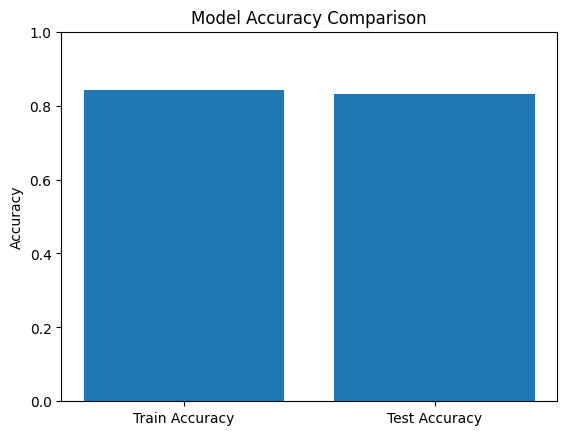

In [294]:
scores = [train_acc, test_acc]
labels = ['Train Accuracy', 'Test Accuracy']

plt.bar(labels, scores)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [295]:
feature_names = X.columns
importances = model.feature_importances_

print("Feature Importances:")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.3f}")

Feature Importances:
  Title: 0.579
  Pclass: 0.159
  Fare: 0.153
  Age: 0.057
  Sex: 0.039
  Embarked: 0.012
  SibSp: 0.000
  Parch: 0.000
  FamilySize: 0.000
  Alone: 0.000




- **Title** is the strongest predictor of survival probability

- Higher passenger class (**Pclass**) and higher **Fare**
  **increase** the chances of survival

- **Age** slightly affects survival probability

- **Sex** has an impact on survival prediction, although lower than Title

- **Embarked** has minimal influence on the model

- Features such as **SibSp**, **Parch**, **FamilySize**, and **Alone**
  showed almost no impact on prediction results

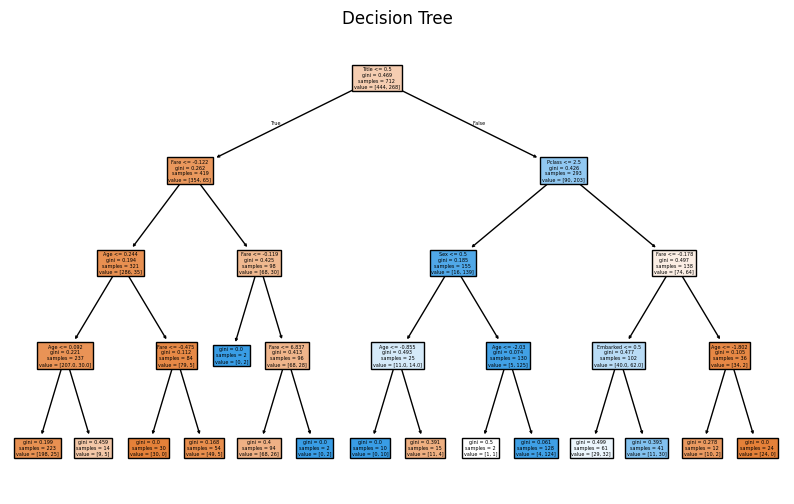

In [296]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure( figsize=(10,6))
plot_tree(model,feature_names=X.columns,filled=True)
plt.title("Decision Tree")
plt.show()

## Model Building: Support Vector Machine (SVM)

In [297]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM is sensitive to feature scales, so we scale the data first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

In [298]:
svm_train_pred = svm_model.predict(X_train_scaled)
print(f"Training Accuracy: {accuracy_score(y_train, svm_train_pred):.2f}")

print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, svm_train_pred))
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")

print("\nTraining Classification Report:\n", classification_report(y_train, svm_train_pred))

Training Accuracy: 0.84

Training Confusion Matrix:
 [[404  40]
 [ 71 197]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])

Training Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       444
           1       0.83      0.74      0.78       268

    accuracy                           0.84       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712



In [299]:
print(f"Test Accuracy: {accuracy_score(y_test, svm_pred):.2f}")

print("\nTest Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")

print("\nTest Classification Report:\n", classification_report(y_test, svm_pred))

Test Accuracy: 0.82

Test Confusion Matrix:
 [[92 13]
 [19 55]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])

Test Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



**Analyzing to ensure no overfitting**

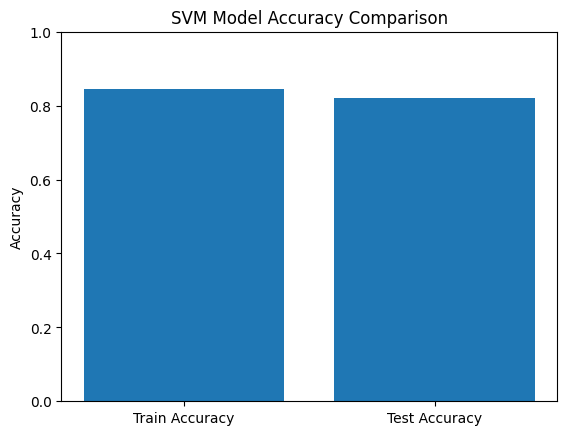

In [300]:
import matplotlib.pyplot as plt

train_acc = accuracy_score(y_train, svm_train_pred)
test_acc = accuracy_score(y_test, svm_pred)

plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc])
plt.ylim(0, 1)
plt.title("SVM Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Model Building: Random Forest

In [301]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [302]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_test_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)
train_acc_forest=accuracy_score(y_train, y_train_pred)
test_acc_forest=accuracy_score(y_test, y_test_pred)
print(f"Training Accuracy:{train_acc_forest*100 :.2f}%")
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))

Training Accuracy:84.41%

Training Confusion Matrix:
 [[403  41]
 [ 70 198]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])

Training Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88       444
           1       0.83      0.74      0.78       268

    accuracy                           0.84       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712



In [303]:

print(f"Test Accuracy: {test_acc_forest*100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\n[[True Negatives (TN), False Positives (FP)]\n [False Negatives (FN), True Positives (TP)]])")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Test Accuracy: 83.24%

Confusion Matrix:
 [[93 12]
 [14 60]]

[[True Negatives (TN), False Positives (FP)]
 [False Negatives (FN), True Positives (TP)]])

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88       105
           1       0.83      0.81      0.82        74

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.85      0.85      0.85       179



**Anlyzing to ensure from over fitting**

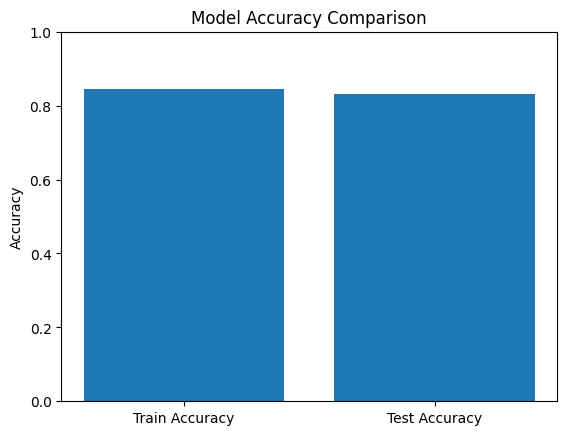

In [304]:
scores = [train_acc_forest, test_acc_forest]
labels = ['Train Accuracy', 'Test Accuracy']

plt.bar(labels, scores)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [305]:
feature_names = X.columns
importances = rf_model.feature_importances_

print("Feature Importances:")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.3f}")

Feature Importances:
  Title: 0.302
  Sex: 0.271
  Fare: 0.111
  Pclass: 0.105
  Age: 0.076
  FamilySize: 0.061
  SibSp: 0.033
  Embarked: 0.017
  Alone: 0.013
  Parch: 0.012



- **Title** is the strongest predictor of survival probability

- **Sex** also plays a major role in prediction
  (**females were more likely to survive**)

- Higher **Fare** and better passenger class (**Pclass**)
  **increase** the chances of survival

- **Age** has a moderate effect on survival prediction

- **FamilySize** and **SibSp** slightly influence survival outcomes

- **Embarked**, **Alone**, and **Parch**
  have relatively small impact on the model predictions